In [10]:
import numpy as np
from ham_reader import ham_reader
import matplotlib.pyplot as plt

In [4]:
raw_teeth_map = ham_reader('../2026-01-14/10us_map_13x10_3shots_teeth.csv')

dark_10us = ham_reader('../2026-01-14/10us_1000_dark.csv')

In [14]:
dark_10us_mean = np.mean(dark_10us, axis=0)

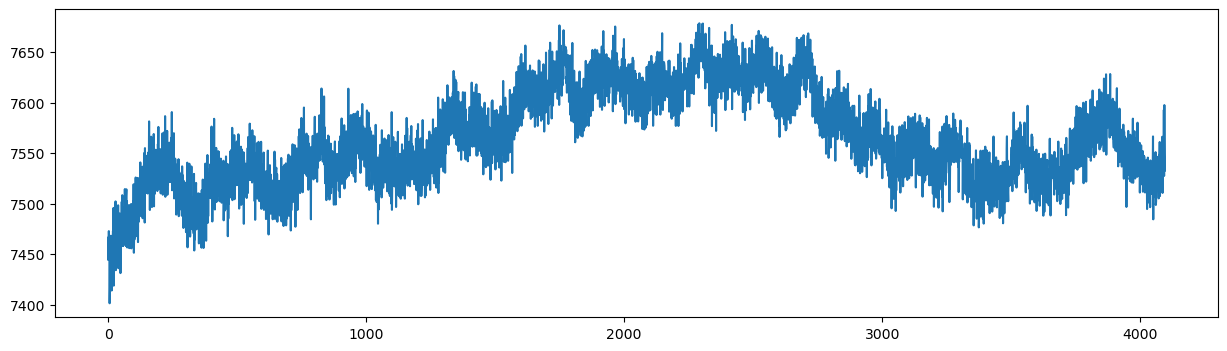

In [16]:
fig, ax = plt.subplots(figsize=(15, 4))

ax.plot(dark_10us_mean)

In [20]:
teeth_map = raw_teeth_map - dark_10us_mean

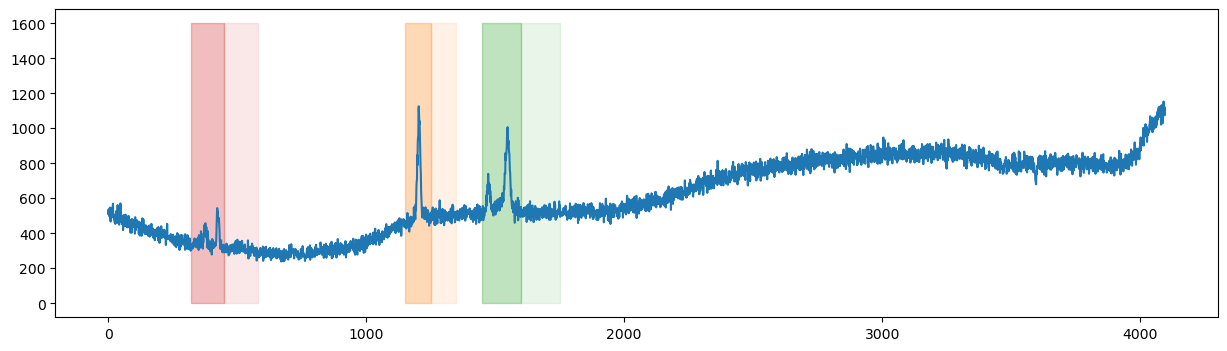

In [130]:
fig, ax = plt.subplots(figsize=(15, 4))

ax.plot(teeth_map[8])
ax.fill_betweenx([0, 1600], 1450, 1600, color='tab:green', alpha=0.3)
ax.fill_betweenx([0, 1600], 1600, 1750, color='tab:green', alpha=0.1)
ax.fill_betweenx([0, 1600], 320, 450, color='tab:red', alpha=0.3)
ax.fill_betweenx([0, 1600], 450, 580, color='tab:red', alpha=0.1)
ax.fill_betweenx([0, 1600], 1150, 1250, color='tab:orange', alpha=0.3)
ax.fill_betweenx([0, 1600], 1250, 1350, color='tab:orange', alpha=0.1)

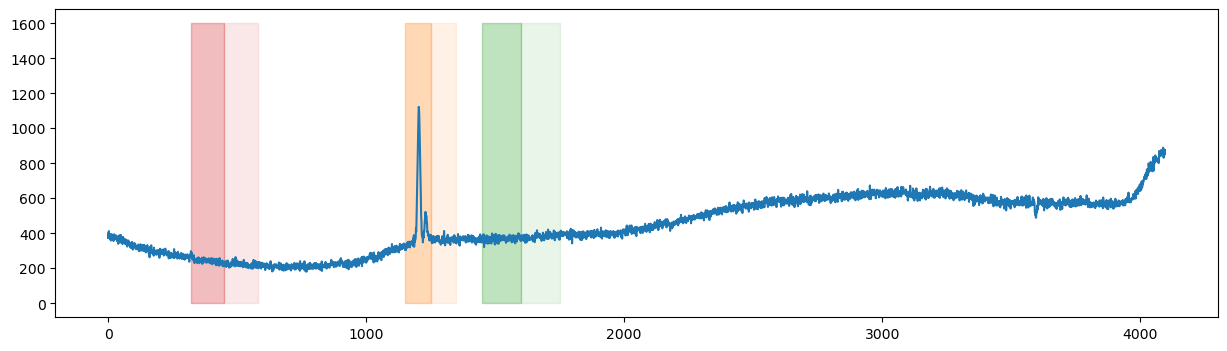

In [131]:
fig, ax = plt.subplots(figsize=(15, 4))

row = 0
col = 12

ax.plot(np.mean([teeth_map[(row * 13 + col) * 3],
                 teeth_map[(row * 13 + col) * 3 + 1],
                 teeth_map[(row * 13 + col) * 3 + 2]], axis=0))
ax.fill_betweenx([0, 1600], 1450, 1600, color='tab:green', alpha=0.3)
ax.fill_betweenx([0, 1600], 1600, 1750, color='tab:green', alpha=0.1)
ax.fill_betweenx([0, 1600], 320, 450, color='tab:red', alpha=0.3)
ax.fill_betweenx([0, 1600], 450, 580, color='tab:red', alpha=0.1)
ax.fill_betweenx([0, 1600], 1150, 1250, color='tab:orange', alpha=0.3)
ax.fill_betweenx([0, 1600], 1250, 1350, color='tab:orange', alpha=0.1)

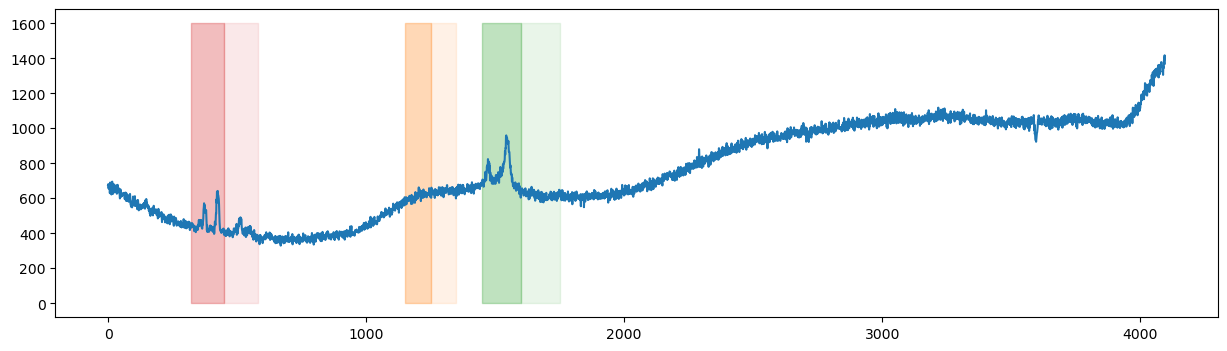

In [134]:
fig, ax = plt.subplots(figsize=(15, 4))

row = 1
col = 0

ax.plot(np.mean([teeth_map[(row * 13 + col) * 3],
                 teeth_map[(row * 13 + col) * 3 + 1],
                 teeth_map[(row * 13 + col) * 3 + 2]], axis=0))
ax.fill_betweenx([0, 1600], 1450, 1600, color='tab:green', alpha=0.3)
ax.fill_betweenx([0, 1600], 1600, 1750, color='tab:green', alpha=0.1)
ax.fill_betweenx([0, 1600], 320, 450, color='tab:red', alpha=0.3)
ax.fill_betweenx([0, 1600], 450, 580, color='tab:red', alpha=0.1)
ax.fill_betweenx([0, 1600], 1150, 1250, color='tab:orange', alpha=0.3)
ax.fill_betweenx([0, 1600], 1250, 1350, color='tab:orange', alpha=0.1)

In [107]:
P_values = np.zeros((13, 10))
for i in range(13):
    for j in range(10):
        index1 = int((j * 13 + i) * 3)
        P_values[i, j] = np.mean([np.sum(teeth_map[index1][1450:1600]),
                                  np.sum(teeth_map[index1 + 1][1450:1600]),
                                  np.sum(teeth_map[index1 + 2][1450:1600])])

P_values_background = np.zeros((13, 10))
for i in range(13):
    for j in range(10):
        index1 = int((j * 13 + i) * 3)
        P_values_background[i, j] = np.mean([np.sum(teeth_map[index1][1600:1750]),
                                             np.sum(teeth_map[index1 + 1][1600:1750]),
                                             np.sum(teeth_map[index1 + 2][1600:1750])])

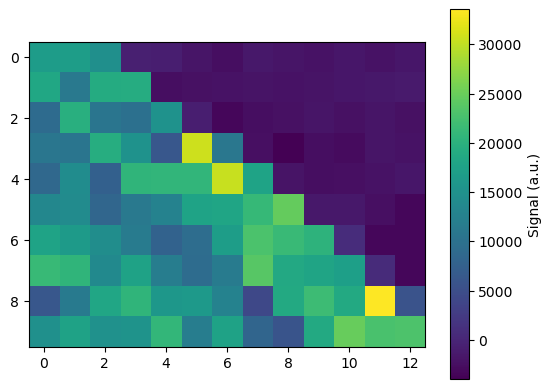

In [145]:
plt.imshow((P_values.T - P_values_background.T), aspect='equal', cmap='viridis')
plt.colorbar(label='Signal (a.u.)')

In [95]:
P2_values = np.zeros((13, 10))
for i in range(13):
    for j in range(10):
        index1 = int((j * 13 + i) * 3)
        P2_values[i, j] = np.mean([np.sum(teeth_map[index1][320:450]),
                                  np.sum(teeth_map[index1 + 1][320:450]),
                                  np.sum(teeth_map[index1 + 2][320:450])])
        
P2_values_background = np.zeros((13, 10))
for i in range(13):
    for j in range(10):
        index1 = int((j * 13 + i) * 3)
        P2_values_background[i, j] = np.mean([np.sum(teeth_map[index1][450:580]),
                                             np.sum(teeth_map[index1 + 1][450:580]),
                                             np.sum(teeth_map[index1 + 2][450:580])])

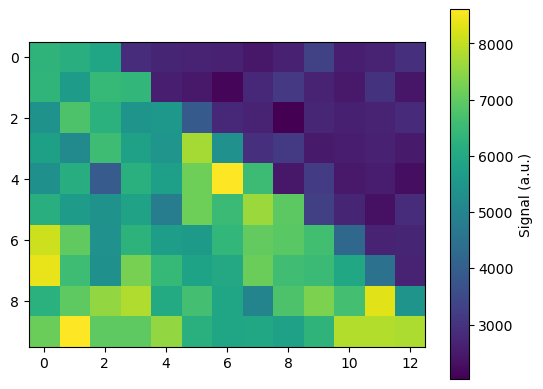

In [142]:
plt.imshow((P2_values.T - P2_values_background.T), aspect='equal', cmap='viridis')
plt.colorbar(label='Signal (a.u.)')

In [127]:
X_values = np.zeros((13, 10))
for i in range(13):
    for j in range(10):
        index1 = int((j * 13 + i) * 3)
        X_values[i, j] = np.mean([np.sum(teeth_map[index1][1150:1250]),
                                  np.sum(teeth_map[index1 + 1][1150:1250]),
                                  np.sum(teeth_map[index1 + 2][1150:1250])])

X_values_background = np.zeros((13, 10))
for i in range(13):
    for j in range(10):
        index1 = int((j * 13 + i) * 3)
        X_values_background[i, j] = np.mean([np.sum(teeth_map[index1][1250:1350]),
                                             np.sum(teeth_map[index1 + 1][1250:1350]),
                                             np.sum(teeth_map[index1 + 2][1250:1350])])

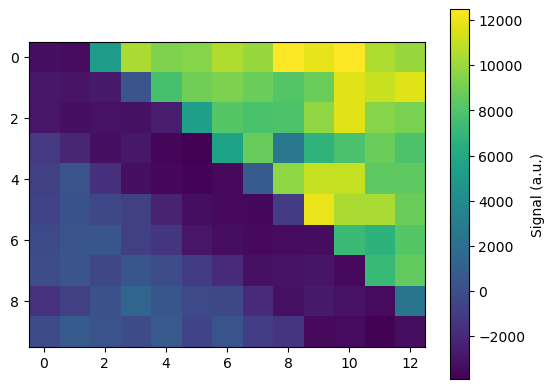

In [143]:
plt.imshow(X_values.T - X_values_background.T, aspect='equal', cmap='viridis')
plt.colorbar(label='Signal (a.u.)')